首先导入进行预测所需的库

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
# import scikeras
# from scikeras.wrappers import KerasRegressor
from math import sqrt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import explained_variance_score
from sklearn.metrics import r2_score

加载数据，并检查输出

In [2]:
df=pd.read_csv("G:/HH_1/Table_Point_1/1.csv",parse_dates=["DATE"],index_col=[0])
df.head()

,NDVI,TEMP,ET0,FAPAR,GPP,LAI,LST,PRE,SIF
DATE,,,,,,,,,
200002,0.140129,0.378571,0.004646,0.055106,0.004641,0.005780,0.476791,0.495833,0.005175
200003,0.181925,0.368590,0.154710,0.058176,0.000843,0.008179,0.437875,0.401042,0.007015
200004,0.205156,0.356419,0.263256,0.071668,0.000263,0.009870,0.417230,0.315747,0.006352
200005,0.233539,0.358108,0.341261,0.113114,0.008892,0.017521,0.249339,0.660038,0.009037
200006,0.403737,0.326786,0.363803,0.303064,0.048914,0.041782,0.281115,0.433011,0.020004


In [3]:
df.tail()

,NDVI,TEMP,ET0,FAPAR,GPP,LAI,LST,PRE,SIF
DATE,,,,,,,,,
202108,0.608611,0.328069,0.447843,0.462589,0.237140,0.069953,0.247330,0.372106,0.066983
202109,0.504103,0.353939,0.492700,0.347652,0.096407,0.042730,0.249104,0.197103,0.030182
202110,0.347084,0.388008,0.527278,0.166996,0.018680,0.015326,0.468339,0.169135,0.007799
202111,0.076267,0.359671,0.147956,0.112130,0.000000,0.009486,0.239260,0.039382,0.001105
202112,0.131911,0.360510,0.016180,0.090316,0.002013,0.009114,0.401815,0.297671,0.002587


csv文件中包含了谷歌从2000-01-01到2021-12-01的数据，数据是按照月频率的<br />试图预测“NDVI_mean”列的未来值，因此“NDVI_mean”是这里的目标列

看一下数据的形状

In [4]:
df.shape

(263, 9)

进行训练测试拆分。这里我们不能打乱数据，因为在时间序列中必须是顺序的。

In [5]:
test_split=round(len(df)*0.20)
print(test_split)
df_for_training=df[:-53]
df_for_testing=df[-53:]
print(df_for_training.shape)
print(df_for_testing.shape)

53
(210, 9)
(53, 9)


可以注意到数据范围非常大，并且它们没有在相同的范围内缩放，因此为了避免预测错误，先使用MinMaxScaler缩放数据。(也可以使用StandardScaler)

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
df_for_training_scaled = scaler.fit_transform(df_for_training)
df_for_testing_scaled=scaler.transform(df_for_testing)
df_for_training_scaled

array([[0.23179394, 0.61659347, 0.00754234, ..., 0.67998447, 0.61786087,
        0.06477086],
       [0.30177925, 0.55946751, 0.25118164, ..., 0.60705411, 0.49974039,
        0.08967342],
       [0.3406786 , 0.4898129 , 0.42741392, ..., 0.56836375, 0.39345389,
        0.08069416],
       ...,
       [0.38536777, 0.47047817, 0.55859554, ..., 0.17102444, 0.49057391,
        0.12384907],
       [0.64630157, 0.28956047, 0.51587441, ..., 0.10898011, 0.98711862,
        0.27876736],
       [0.80739497, 0.07692297, 0.72190065, ..., 0.32946938, 0.2339589 ,
        0.61920226]])

将数据拆分为X和Y，很重要！！！

In [7]:
def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return np.array(dataX),np.array(dataY)
trainX,trainY=createXY(df_for_training_scaled,3)
testX,testY=createXY(df_for_testing_scaled,3)

N_past是我们在预测下一个目标值时将在过去查看的步骤数<br />这里使用3，意味着将使用过去的3个值(包括目标列在内的所有特性)来预测第4个目标值<br />因此，在trainX中我们会有所有的特征值，而在trainY中我们只有目标值<br />让我们分解for循环的每一部分<br />对于训练，dataset = df_for_training_scaled, n_past=3<br />当i= 3:<br />data_X.addend (df_for_training_scaled[i - n_past:i, 0:df_for_training.shape[1]])<br />从n_past开始的范围是3，所以第一次数据范围将是-[3 - 3,5,0:5] 相当于 [0:3,0:5]<br />因此在dataX列表中，df_for_training_scaled[0:3,0:5]数组将第一次出现<br />现在, dataY.append(df_for_training_scaled[i,0])<br />i = 3，所以它将只取第3行开始的NDVI_mean(因为在预测中，我们只需要NDVI_mean列，所以列范围仅为0，表示open列)<br />第一次在dataY列表中存储df_for_training_scaled[5,0]值<br />所以包含5列的前3行存储在dataX中，只有open列的第4行存储在dataY中。然后我们将dataX和dataY列表转换为数组，它们以数组格式在LSTM中进行训练

In [8]:
print("trainX Shape-- ",trainX.shape)
print("trainY Shape-- ",trainY.shape)

trainX Shape--  (207, 3, 9)
trainY Shape--  (207,)


In [9]:
print("testX Shape-- ",testX.shape)
print("testY Shape-- ",testY.shape)

testX Shape--  (50, 3, 9)
testY Shape--  (50,)


208 是 trainX 中可用的数组总数，每个数组共有 3 行和 5 列， 在每个数组的 trainY 中，我们都有下一个目标值来训练模型<br />看一下包含来自 trainX 的 (3,5) 数据的数组之一 和 trainX 数组的 trainY 值

In [10]:
print("trainX[0]-- \n",trainX[0])
print("trainY[0]-- ",trainY[0])

trainX[0]-- 
 [[0.23179394 0.61659347 0.00754234 0.01256618 0.0178876  0.03142005
  0.67998447 0.61786087 0.06477086]
 [0.30177925 0.55946751 0.25118164 0.01969908 0.00324733 0.06652624
  0.60705411 0.49974039 0.08967342]
 [0.3406786  0.4898129  0.42741392 0.05104486 0.00101243 0.09127611
  0.56836375 0.39345389 0.08069416]]
trainY[0]--  0.38820513705256904


如果查看 trainX[1] 值，会发现到它与 trainX[0] 中的数据相同（第一列除外），因为我们将看到前 3 个来预测第 4 列，在第一次预测之后它会自动移动 到第 2 列并取下一个 3 值来预测下一个目标值<br />使用 girdsearchCV 进行一些超参数调整以找到基础模型

In [11]:
def build_model(optimizer):
    grid_model = Sequential()
    grid_model.add(LSTM(units=64,return_sequences=True,input_shape=(3,9),activation='relu'))
    grid_model.add(LSTM(units=32,return_sequences=True,activation='relu'))
    grid_model.add(LSTM(units=16,return_sequences=True,activation='relu'))
    grid_model.add(LSTM(units=8,activation='relu'))
    grid_model.add(Dropout(0.5))
    grid_model.add(Dense(1))

    grid_model.compile(loss = 'mse',optimizer = optimizer, metrics=['accuracy'])
    return grid_model

grid_model = KerasRegressor(build_fn=build_model,verbose=1)
parameters = {'batch_size' : [4,8,16,32,64,128],
              'epochs' : [5,10,20,50,100,150,200],
              'optimizer' : ['SGD', 'adam', 'Momentum', 'Adagrad', 'RMSProp'] }

grid_search  = GridSearchCV(estimator = grid_model,#选择使用的分类器，并且传入除需要确定最佳的参数之外的其他参数
                            param_grid = parameters,#需要最优化的参数的取值，值为字典或者列表
                            cv = 2)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5680\753935663.py:13: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  grid_model = KerasRegressor(build_fn=build_model,verbose=1)


在第一个 LSTM 层中看到输入形状为 (3,5)。它来自 trainX 形状。(trainX.shape[1],trainX.shape[2]) → (3,5)<br />将模型拟合到 trainX 和 trainY 数据中

In [12]:
grid_search_results = grid_search.fit(trainX, trainY, validation_data=(testX, testY),verbose=1)

Epoch 1/5
26/26 [==============================] - 3s 21ms/step - loss: 0.2174 - accuracy: 0.0000e+00 - val_loss: 0.1718 - val_accuracy: 0.0000e+00
Epoch 2/5
26/26 [==============================] - 0s 4ms/step - loss: 0.1137 - accuracy: 0.0000e+00 - val_loss: 0.1234 - val_accuracy: 0.0000e+00
Epoch 3/5
26/26 [==============================] - 0s 4ms/step - loss: 0.0854 - accuracy: 0.0000e+00 - val_loss: 0.1098 - val_accuracy: 0.0000e+00
Epoch 4/5
26/26 [==============================] - 0s 4ms/step - loss: 0.0726 - accuracy: 0.0000e+00 - val_loss: 0.1055 - val_accuracy: 0.0000e+00
Epoch 5/5
26/26 [==============================] - 0s 1ms/step - loss: 0.0660 - accuracy: 0.0096
Epoch 1/5
26/26 [==============================] - 2s 15ms/step - loss: 0.2205 - accuracy: 0.0096 - val_loss: 0.1828 - val_accuracy: 0.0000e+00
Epoch 2/5
26/26 [==============================] - 0s 3ms/step - loss: 0.1115 - accuracy: 0.0096 - val_loss: 0.1274 - val_accuracy: 0.0000e+00
Epoch 3/5
26/26 [==========

d:\anaconda\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
84 fits failed out of a total of 420.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
84 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\anaconda\lib\site-packages\keras\wrappers\scikit_learn.py", line 164, in fit
    self.model = self.build_fn(**self.filter_sk_params(self.build_fn))
  File "C:\Users\Administrator\AppData\Local\Temp\ipykernel_5680\753935663.py", line 10, in build_model
    grid_model.compile(loss = 'mse',optimizer = optimizer, metrics=['acc

52/52 [==============================] - 3s 13ms/step - loss: 0.2242 - accuracy: 0.0048 - val_loss: 0.1339 - val_accuracy: 0.0000e+00
Epoch 2/100
52/52 [==============================] - 0s 6ms/step - loss: 0.1168 - accuracy: 0.0048 - val_loss: 0.0944 - val_accuracy: 0.0000e+00
Epoch 3/100
52/52 [==============================] - 0s 6ms/step - loss: 0.1116 - accuracy: 0.0048 - val_loss: 0.1151 - val_accuracy: 0.0000e+00
Epoch 4/100
52/52 [==============================] - 0s 6ms/step - loss: 0.0903 - accuracy: 0.0097 - val_loss: 0.0964 - val_accuracy: 0.0000e+00
Epoch 5/100
52/52 [==============================] - 0s 5ms/step - loss: 0.0855 - accuracy: 0.0000e+00 - val_loss: 0.0923 - val_accuracy: 0.0000e+00
Epoch 6/100
52/52 [==============================] - 0s 6ms/step - loss: 0.0756 - accuracy: 0.0048 - val_loss: 0.0914 - val_accuracy: 0.0000e+00
Epoch 7/100
52/52 [==============================] - 0s 5ms/step - loss: 0.0849 - accuracy: 0.0048 - val_loss: 0.0780 - val_accuracy: 0.0

In [13]:
history = grid_search_results.best_estimator_.model.history

In [14]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [15]:
import time

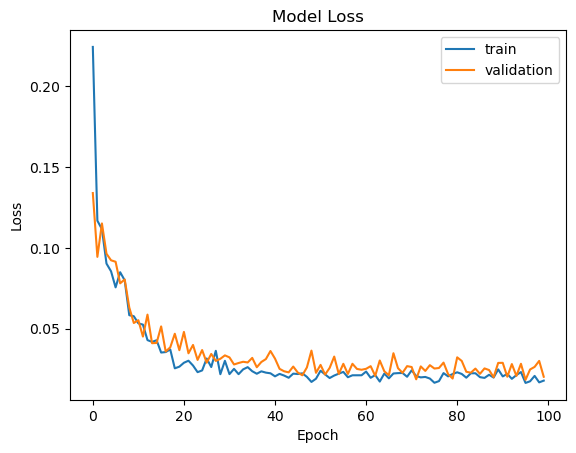

In [16]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()
time.sleep(1)
plt.close()

检查模型的最佳参数

In [17]:
grid_search_results.best_params_

{'batch_size': 4, 'epochs': 100, 'optimizer': 'RMSProp'}

将最佳模型保存在 my_model 变量中

In [18]:
my_model=grid_search_results.best_estimator_.model

现在用测试数据集测试模型

In [19]:
prediction=my_model.predict(testX)
print("prediction\n", prediction)
print("\nPrediction Shape-",prediction.shape)

2/2 [==============================] - 0s 3ms/step
prediction
 [[0.3658221 ]
 [0.3369954 ]
 [0.33731622]
 [0.38291243]
 [0.37277845]
 [0.38353217]
 [0.45776007]
 [0.71035534]
 [0.8472693 ]
 [0.9275336 ]
 [0.8151818 ]
 [0.49922878]
 [0.34910768]
 [0.33720267]
 [0.34304082]
 [0.37660322]
 [0.3678456 ]
 [0.3807857 ]
 [0.5221178 ]
 [0.7838712 ]
 [0.89479816]
 [0.93688726]
 [0.76569104]
 [0.49461243]
 [0.36501426]
 [0.34449387]
 [0.3578921 ]
 [0.384203  ]
 [0.38662454]
 [0.3954196 ]
 [0.50510514]
 [0.73662055]
 [0.87631583]
 [0.92039746]
 [0.8444083 ]
 [0.5212268 ]
 [0.3554278 ]
 [0.33726346]
 [0.34827623]
 [0.36597735]
 [0.37533134]
 [0.38477767]
 [0.46495587]
 [0.783229  ]
 [0.97398794]
 [1.0032693 ]
 [0.85073555]
 [0.49222365]
 [0.3446143 ]
 [0.3339869 ]]

Prediction Shape- (50, 1)


testY 和 prediction 的长度是一样的。现在可以将 testY 与预测进行比较
但是一开始就对数据进行了缩放，所以首先必须做一些逆缩放过程

In [20]:
prediction_copies_array = np.repeat(prediction,9, axis=-1)
prediction_copies_array.shape

(50, 9)

In [21]:
pred=scaler.inverse_transform(np.reshape(prediction_copies_array,(len(prediction),9)))[:,0]

将这个 pred 值与 testY 进行比较，但是 testY 也是按比例缩放的，也需要使用与上述相同的代码进行逆变换

In [22]:
original_copies_array = np.repeat(testY,9, axis=-1)
original=scaler.inverse_transform(np.reshape(original_copies_array,(len(testY),9)))[:,0]

In [23]:
print("Pred Values-- " ,pred)
print("\nOriginal Values-- " ,original)

Pred Values--  [0.22017154 0.20295602 0.20314762 0.230378   0.22432591 0.23074812
 0.27507752 0.42592922 0.5076952  0.5556296  0.4885323  0.29984292
 0.21018957 0.2030798  0.2065664  0.2266101  0.22137998 0.2291079
 0.3135124  0.46983337 0.53607976 0.56121564 0.45897606 0.29708603
 0.21968909 0.20743416 0.21543568 0.23114873 0.2325949  0.23784737
 0.30335236 0.44161496 0.525042   0.5513678  0.5059866  0.31298032
 0.21396399 0.20311612 0.20969301 0.22026426 0.22585052 0.23149194
 0.27937493 0.46944985 0.5833724  0.60085946 0.50976527 0.29565942
 0.20750609 0.20115933]

Original Values--  [0.01856026 0.19231538 0.19688623 0.20461345 0.20425871 0.21000461
 0.2823162  0.50240029 0.60578959 0.62084005 0.49950947 0.32310698
 0.05574187 0.04503731 0.05509821 0.04409228 0.04792698 0.23685353
 0.30392446 0.48185748 0.59018316 0.56832017 0.49332598 0.34955748
 0.20782693 0.20908369 0.02477927 0.02661818 0.06215771 0.1966194
 0.26171931 0.47720335 0.60042108 0.61653179 0.52798623 0.38153608
 0.23

绘制一个图来对比 pred 和原始数据

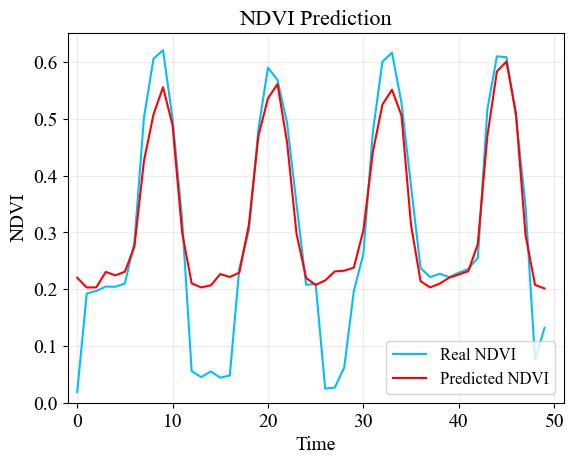

In [24]:
plt.plot(original, color = 'deepskyblue', label = 'Real NDVI')
plt.plot(pred, color = 'red', label = 'Predicted NDVI')
plt.title('NDVI Prediction', fontsize=16, fontname="Times New Roman")
plt.xlabel('Time', fontsize=14, fontname="Times New Roman")
plt.ylabel('NDVI', fontsize=14, fontname="Times New Roman")
plt.grid(True, which="major", axis="both", alpha=0.15, color="gray")
plt.legend(prop={"size": 12, "family": "Times New Roman"})
plt.ylim(0)
plt.xlim(-1,51)
plt.xticks(fontname="Times New Roman", fontsize=14)
plt.yticks(fontname="Times New Roman", fontsize=14)
plt.savefig('E:/1.jpg')
plt.show()


输出pred到txt

In [25]:
f = open("E:/1.csv","w")
pd.set_option('display.max_columns', None)   
pd.set_option('display.max_rows', None)  
print(pred,file=f)
f.close()

In [26]:
np.savetxt("E:/1.csv", pred, delimiter=",", comments="")

In [27]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    """ Mean Directional Accuracy """
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

def mean_absolute_percentage_error(original, pred): 
    y_true, y_pred = np.array(original), np.array(original)
    return np.mean(np.abs((original - pred) / original)) * 100

In [28]:
r2 = r2_score(original, pred)
print('R2 value of the LSTM Model is:', r2)

MAE_lstm = mean_absolute_error(original, pred)
print('MAE value of the LSTM Model is:', MAE_lstm)

MDA_lstm = mda(original, pred)
print('MDA value of the LSTM Model is:', MDA_lstm)

MAPE_lstm = mean_absolute_percentage_error(original, pred)
print('MAPE value of the LSTM Model is:', MAPE_lstm)

RMSE_lstm = sqrt(mean_squared_error(original,pred, squared=False))
print('RMSE value of the LSTM Model is:', RMSE_lstm)

MSE_lstm = mean_squared_error(original,pred)
print('MSE value of the LSTM Model is:', MSE_lstm)

EVS_lstm = explained_variance_score(original, pred)
print('EVS score of the LSTM Model is:', EVS_lstm)

R2 value of the LSTM Model is: 0.8057143184788964
MAE value of the LSTM Model is: 0.05844225034846449
MDA value of the LSTM Model is: 0.8163265306122449
MAPE value of the LSTM Model is: 102.06247493935116
RMSE value of the LSTM Model is: 0.2916465377066631
MSE value of the LSTM Model is: 0.007234812832199452
EVS score of the LSTM Model is: 0.8184447639415346


In [29]:
import csv

data = [[r2], [MAE_lstm], [MDA_lstm], [MAPE_lstm], [RMSE_lstm], [MSE_lstm], [EVS_lstm]]

with open('E:/data.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    for row in data:
        writer.writerow(row)


预测一些未来值<br />从主 df 数据集中获取我们在开始时加载的最后 3 个值[为什么是 3？因为这是想要的过去值的数量，来预测第 4 个值]

In [30]:
df_36_monthes_past=df.iloc[-36:,:]
df_36_monthes_past.tail()

,NDVI,TEMP,ET0,FAPAR,GPP,LAI,LST,PRE,SIF
DATE,,,,,,,,,
202108,0.608611,0.328069,0.447843,0.462589,0.237140,0.069953,0.247330,0.372106,0.066983
202109,0.504103,0.353939,0.492700,0.347652,0.096407,0.042730,0.249104,0.197103,0.030182
202110,0.347084,0.388008,0.527278,0.166996,0.018680,0.015326,0.468339,0.169135,0.007799
202111,0.076267,0.359671,0.147956,0.112130,0.000000,0.009486,0.239260,0.039382,0.001105
202112,0.131911,0.360510,0.016180,0.090316,0.002013,0.009114,0.401815,0.297671,0.002587


在多元时间序列预测中，需要通过使用不同的特征来预测单列，所以在进行预测时我们需要使用特征值（目标列除外）来进行即将到来的预测。

这里需要其他列的即将到来的 36 个值来对“NDVI_mean”列进行预测。

In [31]:
df_36_monthes_future=pd.read_csv("./data_pred.csv",parse_dates=["DATE"],index_col=[0])
df_36_monthes_future.tail()

FileNotFoundError: [Errno 2] No such file or directory: './data_pred.csv'

缩放数据，因为删除了‘NDVI_mean’列，在缩放它之前，添加一个所有值都为“0”的NDVI_mean列。

缩放后，将未来数据中的“NDVI_mean”列值替换为“nan”

现在附加 36 旧值和 36 天新值（其中最后 36 个“打开”值是 nan）

In [ ]:
df_36_monthes_future["NDVI_mean"]=0
df_36_monthes_future=df_36_monthes_future[["NDVI_mean","temp_mean","precip_mean","ET0_mean","LST_mean"]]
old_scaled_array=scaler.transform(df_36_monthes_past)
new_scaled_array=scaler.transform(df_36_monthes_future)
new_scaled_df=pd.DataFrame(new_scaled_array)
new_scaled_df.iloc[:,0]=np.nan
full_df=pd.concat([pd.DataFrame(old_scaled_array),new_scaled_df]).reset_index().drop(["index"],axis=1)

要进行预测必须再次使用 for 循环，我们在拆分 trainX 和 trainY 中的数据时所做的。但是这次我们只有 X，没有 Y 值

In [ ]:
full_df_scaled_array=full_df.values
all_data=[]
time_step=36
for i in range(time_step,len(full_df_scaled_array)):
    data_x=[]
    data_x.append(full_df_scaled_array[i-time_step :i , 0:full_df_scaled_array.shape[1]])
    data_x=np.array(data_x)
    prediction=my_model.predict(data_x)
    all_data.append(prediction)
    full_df.iloc[i,0]=prediction

对于第一个预测，有之前的 3 个值，当 for 循环第一次运行时它会检查前 3 个值并预测第 4 个“NDVI_mean”数据。

当第二个 for 循环将尝试运行时，它将跳过第一行并尝试获取下 3 个值 [1:3] 。这里会报错错误因为Open列最后一行是 “nan”，所以需要每次都用预测替换“nan”。

最后还需要对预测进行逆变换

In [ ]:
new_array=np.array(all_data)
new_array=new_array.reshape(-1,1)
prediction_copies_array = np.repeat(new_array,5, axis=-1)
y_pred_future_36_monthes = scaler.inverse_transform(np.reshape(prediction_copies_array,(len(new_array),5)))[:,0]
print(y_pred_future_36_monthes)

[0.21732035 0.26085287 0.40112212 0.5918822  0.66803753 0.6528441
 0.6347116  0.5958618  0.5469604  0.49132442 0.4482114  0.42478
 0.42685097 0.46040788 0.5191415  0.57556576 0.6086787  0.62027687
 0.61854136 0.602993   0.56951886 0.52027655 0.47290224 0.44059756
 0.42874318 0.44688883 0.49562895 0.55117905 0.591419   0.6119773
 0.6154737  0.60335207 0.57177067 0.5243654  0.47276872 0.44092113
 0.42956144]
